In [1]:
import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
sys.path.append('/local/hpaugnat/lensqso-specfit')

from multi_spectrum import MultiSpectrum
from multi_spec_fitter import Optimizer, PSO

In [2]:
from QSO_spectral_features import FeIITemplateLines

a = FeIITemplateLines()

-5534913.433655007


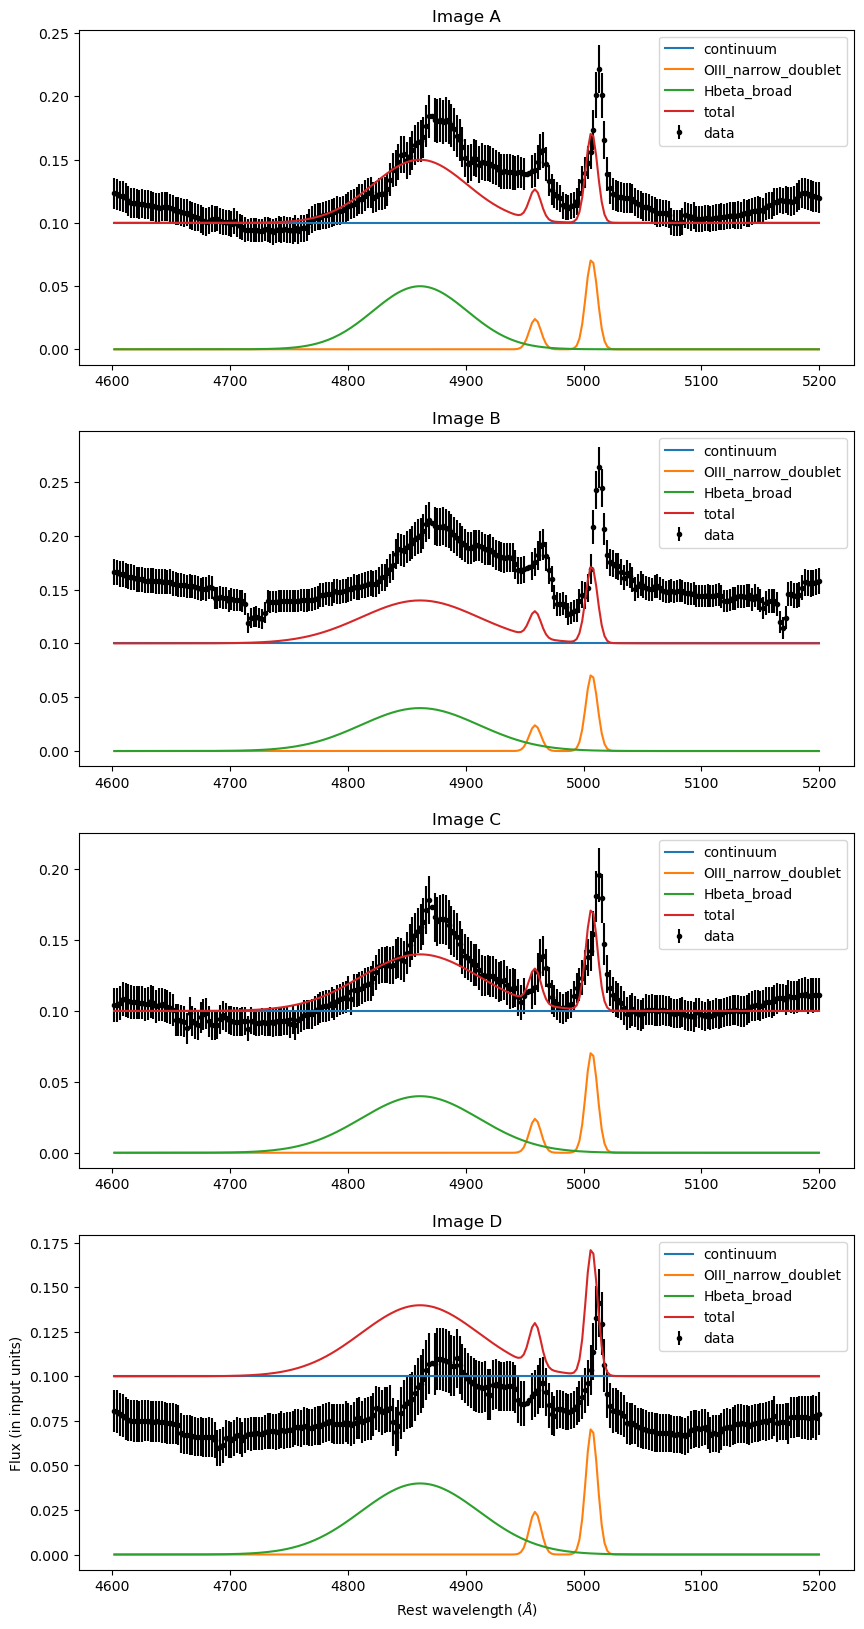

In [24]:
kwargs_data = {}
for image_name in ['A', 'B', 'C', 'D']:
    kwargs_data[image_name] = np.load('example_spectrum_'+image_name+'.npy')


kwargs_model = {'continuum': ('polynomial',1), 
                'narrow_doublets': [('OIII',3)], 
                'single_lines': [('Hbeta',3, 'broad')],
                'Template_lines': []} 

kwargs_fixed = {'ref_image': 'A', 
                'fixed_params':{'OIII_narrow_doublet':['dlam', 'width', 'coeffsHermite'],
                                'Hbeta_broad':[],
                               #'FeII_template': ['dlam', 'velocity', 'G', 'IZw1', 'S']
                               }}

qso_spec = MultiSpectrum(kwargs_data=kwargs_data, kwargs_model=kwargs_model, kwargs_fixed=kwargs_fixed)
#print(qso_spec.param_handler.kwargs_values_mult)
qso_spec.set_priors('continuum', {'amp':[0.1,0.01,0,1]})
qso_spec.set_priors('OIII_narrow_doublet', {'width':[5,0.1,0,10], 'amp':[0.3,0.05,0,10]}, images='all')
qso_spec.set_priors('Hbeta_broad', {'amp':[5,0.1,0,100]}, images='all')
qso_spec.set_priors('Hbeta_broad', {'width':[40, 10, 10, 400]}, images=['A'])
qso_spec.set_initial_values()
#print(qso_spec.param_handler.kwargs_values_mult)

simulated_flux = qso_spec.simulateSpectra(plot=True)
print(qso_spec.log_likelihood_from_kwargs())

#print(qso_spec.param_handler.free_param_list)
array = qso_spec.param_handler.kwargs2array()
#print(array)
#print(qso_spec.param_handler.array2kwargs(array))

 26%|████████████████████▍                                                         | 2618/10000 [02:50<07:59, 15.39it/s]


Converged after 2618 iterations!
Best fit found:  -1453.0911959103005 [0.11923434578164005, 9.3141053346082e-06, 0.30688283814142403, -1.8563247158688312, 6.189597492260692, -0.06175834840240513, 0.13644151226045942, 0.03524365268518312, 4.738116574146817, 1.3145152109094924, 33.53456798251623, 0.2706586320732083, -0.08768370635935852, 0.029418691219280858, 0.15271630377377016, 1.148457954378838e-05, 0.28975528662982847, 5.248290781918199, 0.37978852371102145, 35.73083566380189, 0.010543638459392529, -0.0160478934203903, -0.011360477209565475, 0.0999211895493278, 7.772155042788454e-06, 0.2442594423273436, 4.677580682271612, -2.003721581593966, 20.002165754061163, -0.3135468397369436, 0.15485291238342816, -0.09209941068045076, 0.07899370817453799, 1.341876266076645e-05, 0.23660353308780893, 1.2285824378719838, 39.999174860975494, 41.85421823965958, -0.0032128165333687587, 0.05773743562178453, 0.4455956940406469]
-1453.0963798902253


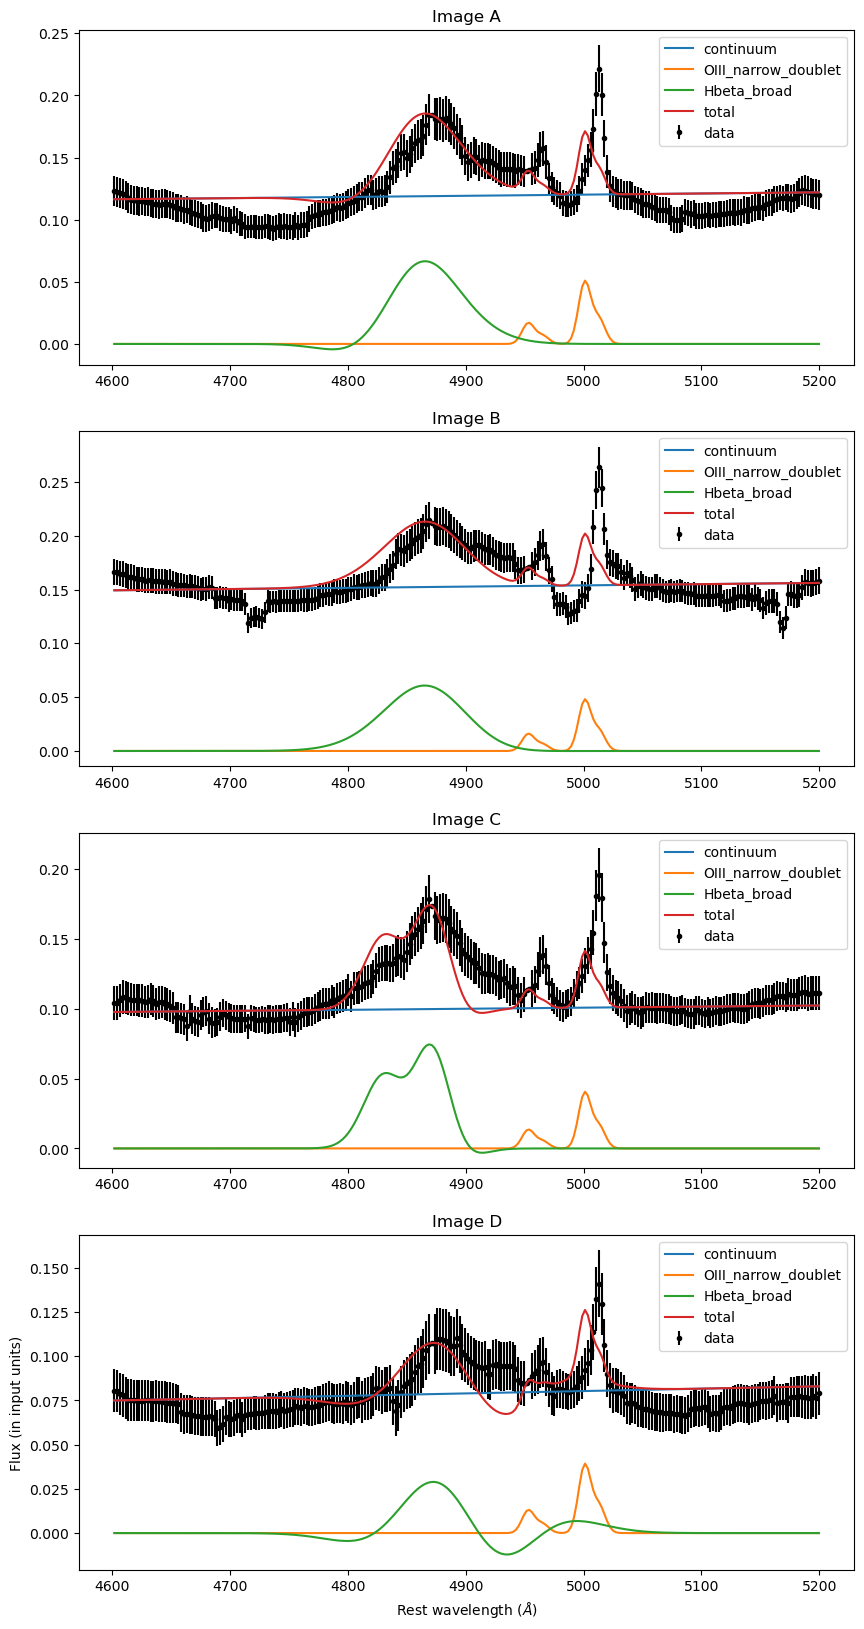

In [25]:
opt = PSO(qso_spec, n_particles=100)
opt.optimize(max_iter=10000)
simulated_flux = qso_spec.simulateSpectra(plot=True)
print(qso_spec.log_likelihood_from_kwargs())

In [23]:
print(print(qso_spec.param_handler.kwargs_values_mult))

{'A': {'continuum': {'amp': 0.11551367263899126, 'coeffs': array([2.60194941e-05])}, 'OIII_narrow_doublet': {'amp': 0.20055554273909817, 'dlam': -0.6597929761003918, 'width': 8.566873262852651, 'coeffsHermite': array([], dtype=float64)}, 'Hbeta_broad': {'amp': 8.496700523025286, 'dlam': 5.907084088882664, 'width': 48.57867176337611, 'coeffsHermite': array([], dtype=float64)}}, 'B': {'continuum': {'amp': 0.1458053544913544, 'coeffs': array([7.0719318e-06])}, 'OIII_narrow_doublet': {'amp': 0.2902837979449502, 'dlam': -0.6597929761003918, 'width': 8.566873262852651, 'coeffsHermite': array([], dtype=float64)}, 'Hbeta_broad': {'amp': 8.108903332311277, 'dlam': 4.522654796883579, 'width': 48.23493651512598, 'coeffsHermite': array([], dtype=float64)}}, 'C': {'continuum': {'amp': 0.1056214575357647, 'coeffs': array([3.63674525e-05])}, 'OIII_narrow_doublet': {'amp': 0.15639853200308315, 'dlam': -0.6597929761003918, 'width': 8.566873262852651, 'coeffsHermite': array([], dtype=float64)}, 'Hbeta_b